In [27]:
from pathlib import Path  # filesystem path handling

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # numerical array operations
import seaborn as sns

from quantnado import BamStore  # main BAM signal store class
from quantnado.dataset.counts import feature_counts  # count reads over genomic features
from quantnado.dataset.features import load_gtf  # parse GTF annotation files
from quantnado.dataset.metadata import extract_metadata  # retrieve sample metadata as DataFrame
from quantnado.dataset.pca import plot_pca_scatter, plot_pca_scree, run_pca  # PCA utilities
from quantnado.dataset.reduce import reduce_byranges_signal  # summarise signal over genomic regions

In [4]:
fig_dir = Path("2026-03-05_multiomics_run/figures")  # path to directory where figures will be saved
fig_dir.mkdir(exist_ok=True)  # create it if it doesn't already exist

# Create Dataset

In [ ]:
# %%bash
# mapfile -t BAM_FILES < <(find 2026-03-05_multiomics_run/seqnado_output -iname "*.bam")

# quantnado create-dataset \
#     --output 2026-03-05_multiomics_run/seqnado_output/dataset \
#     --log-file 2026-03-05_multiomics_run/seqnado_output/dataset_creation.log \
#     --max-workers 4 \
#     --verbose \
#     --overwrite \
#     "${BAM_FILES[@]}"

2026-03-05 14:13:15 [INFO] Processing 11 BAM files into 2026-03-05_multiomics_run/seqnado_output/dataset
2026-03-05 14:13:15 [INFO] Extracting chromsizes from 2026-03-05_multiomics_run/seqnado_output/meth/aligned/meth-rep1.bam
[W::hts_idx_load3] The index file is older than the data file: 2026-03-05_multiomics_run/seqnado_output/meth/aligned/meth-rep1.bam.bai
2026-03-05 14:13:15 [WARNING] Deleting existing store at: 2026-03-05_multiomics_run/seqnado_output/dataset.zarr
2026-03-05 14:13:17 [INFO] Initialized Zarr store at 2026-03-05_multiomics_run/seqnado_output/dataset.zarr
2026-03-05 14:13:17 [INFO] Processing sample 1/11: meth-rep1
2026-03-05 14:13:17 [INFO] Processing sample 2/11: meth-rep2
2026-03-05 14:13:17 [INFO] Processing sample 3/11: atac
2026-03-05 14:13:17 [INFO] Processing sample 4/11: rna-spikein-treated-rep1
2026-03-05 14:13:19 [INFO] Processing sample 5/11: rna-spikein-control-rep2
2026-03-05 14:13:19 [INFO] Processing sample 6/11: rna-spikein-control-rep1
2026-03-05 14

# Load Dataset

In [33]:
ds_path = "2026-03-05_multiomics_run/seqnado_output/dataset.zarr"  # path to the Zarr store on disk
ds = BamStore.open(ds_path)  # open the existing store in read-only mode (default)

2026-03-05 14:13:48.382 | INFO     | quantnado.dataset.bam:_load_existing:282 - Resuming existing store at 2026-03-05_multiomics_run/seqnado_output/dataset.zarr


# Explore Zarr Dataset



In [ ]:
print(ds.sample_names)  # list all sample names stored in the dataset
metadata_df = ds.get_metadata()  # retrieve all sample metadata as a DataFrame
metadata_df

['meth-rep1', 'meth-rep2', 'atac', 'rna-spikein-treated-rep1', 'rna-spikein-control-rep2', 'rna-spikein-control-rep1', 'rna-spikein-treated-rep2', 'rna', 'snp', 'chip-rx_MLL', 'chip-rx_input']


,sample_hash,completed,sparsity
sample_id,,,
meth-rep1,2ee7d73993b16e26770b08ff36418e26,True,94.216675
meth-rep2,7095a0f8d4ee77fd2f612b500189bd23,True,93.745697
atac,af991a1433997c522ecfacb49ee5365a,True,99.904594
rna-spikein-treated-rep1,067d1b918c2023367e83b966546d9846,True,96.408737
rna-spikein-control-rep2,a6dc54b0f51a9b9f6f7edb798ac27187,True,98.167877
rna-spikein-control-rep1,34dc6d8d05fdc2e8a5fe630e1ad04fb0,True,97.987144
rna-spikein-treated-rep2,39c52651c078417b0ca52de5f15e90b5,True,96.751144
rna,d203b5296ccb1cd2d73cc1736f3d356e,True,95.530243
snp,NaN,True,99.945015


In [ ]:
# Check BamStore structure
print("Samples:", ds.sample_names)  # all sample names in store order
print("\nChromosomes:", ds.chromosomes)  # chromosomes present in the store
print(
    "\nChromsizes (first 5):", dict(list(ds.chromsizes.items())[:5])
)  # first 5 chromosome sizes (bp)
print("\nTotal samples:", ds.n_samples)  # progress: completed vs total samples
print("\nMetadata columns:", ds.list_metadata_columns())  # available metadata fields
print("\nRoot attributes:", dict(ds.root.attrs))  # all raw Zarr root attributes

Samples: ['meth-rep1', 'meth-rep2', 'atac', 'rna-spikein-treated-rep1', 'rna-spikein-control-rep2', 'rna-spikein-control-rep1', 'rna-spikein-treated-rep2', 'rna', 'snp', 'chip-rx_MLL', 'chip-rx_input']

Chromosomes: ['chr21']

Chromsizes (first 5): {'chr21': 46709983}

Total samples: 11

Metadata columns: []

Root attributes: {'chromosomes': ['chr21'], 'chromsizes': {'chr21': 46709983}, 'n_samples': 11, 'chunk_len': 65536, 'structure': 'per-chromosome (sample x position)', 'bin_size': 1, 'sample_names': ['meth-rep1', 'meth-rep2', 'atac', 'rna-spikein-treated-rep1', 'rna-spikein-control-rep2', 'rna-spikein-control-rep1', 'rna-spikein-treated-rep2', 'rna', 'snp', 'chip-rx_MLL', 'chip-rx_input'], 'sample_names_hash': '5968502584456e9b', 'average_sparsity': 97.07589721679688}


# Reduce by BED file

In [ ]:
promoters = (
    "2026-03-05_multiomics_run/promoters_1024bp.bed"  # BED file with 1024 bp promoter windows
)

# Summarise per-base signal over each promoter region by taking the mean across positions
promoter_ds = reduce_byranges_signal(ds, intervals_path=promoters, reduction="mean")
promoter_ds

2026-03-05 14:13:54.636 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset
2026-03-05 14:13:54.638 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.Dataset> Size: 415kB
Dimensions:       (ranges: 1456, sample: 11)
Coordinates:
  * ranges        (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    range_index   (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    start         (ranges) int64 12kB 5011852 5011852 ... 46604570 46604570
    end           (ranges) int64 12kB 5012876 5012876 ... 46605594 46605594
    range_length  (ranges) int64 12kB 1024 1024 1024 1024 ... 1024 1024 1024
    contig        (ranges) object 12kB 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand        (ranges) object 12kB '+' '+' '+' '+' '+' ... '-' '-' '-' '-'
    name          (ranges) object 12kB 'LOC124905051:XM_047441065.1' ... 'S10...
  * sample        (sample) <U24 1kB 'meth-rep1' 'meth-rep2' ... 'chip-rx_input'
Data variables:
    sum           (ranges, sample) float32 64kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    count         (ranges, sample) int64 128kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    mean          (ranges, sample) float64 128kB dask.array<chunksize=(1456, 1), meta=np.ndarray>

/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


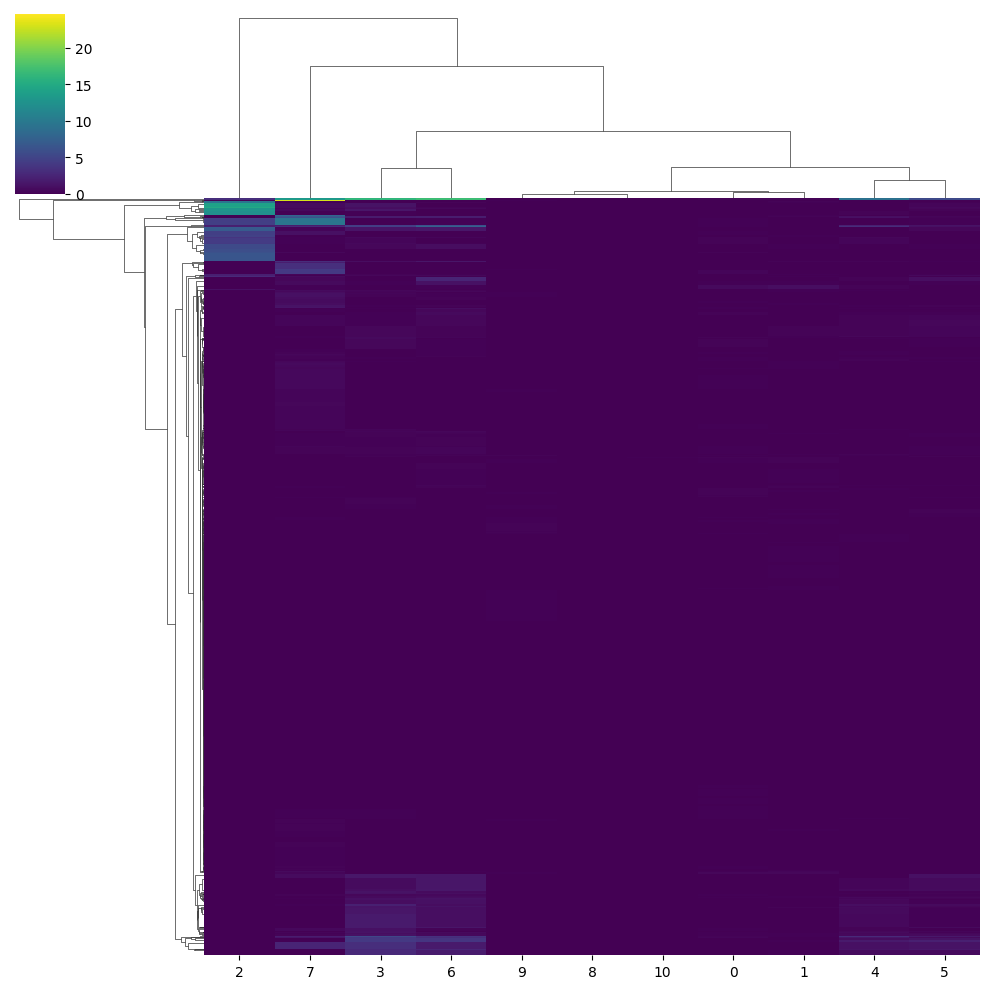

In [ ]:
data = promoter_ds["mean"].values  # (ranges × samples)
sample_names = promoter_ds["sample"].values  # sample names in the same order as columns of `data`
sns.clustermap(data, cmap="viridis", yticklabels=False)

/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado_dev/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: >

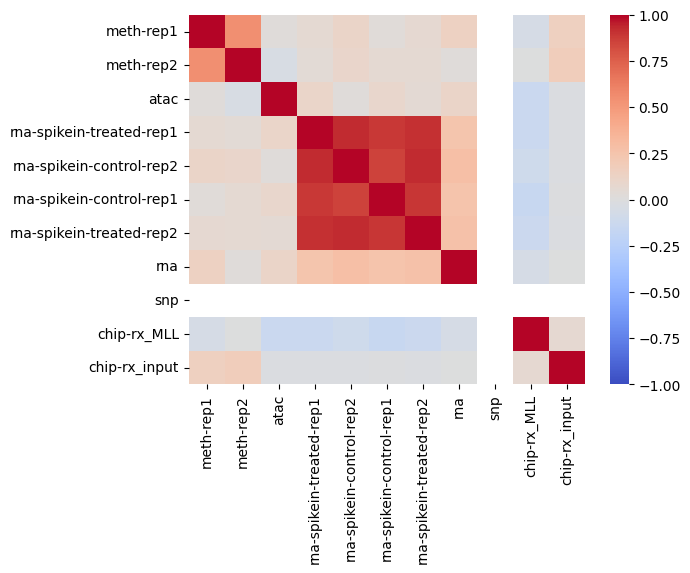

In [38]:
data = promoter_ds["mean"].values.T  # (samples × ranges)
corr = np.corrcoef(data)
sns.heatmap(
    corr, xticklabels=ds.sample_names, yticklabels=ds.sample_names, cmap="coolwarm", vmin=-1, vmax=1
)